# 实战项目：房价影响因素的对数模型分析

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import statsmodels.formula.api as smf
import scipy.stats as st
from itables import show
from ydata_profiling import ProfileReport
#加载主题包
from jupyterthemes import jtplot
jtplot.style(theme='oceans16')

#多行打印设置
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [38]:
import wooldridge

In [39]:
df = wooldridge.data('hprice1', description=True)

name of dataset: hprice1
no of variables: 10
no of observations: 88

+----------+------------------------------+
| variable | label                        |
+----------+------------------------------+
| price    | house price, $1000s          |
| assess   | assessed value, $1000s       |
| bdrms    | number of bdrms              |
| lotsize  | size of lot in square feet   |
| sqrft    | size of house in square feet |
| colonial | =1 if home is colonial style |
| lprice   | log(price)                   |
| lassess  | log(assess                   |
| llotsize | log(lotsize)                 |
| lsqrft   | log(sqrft)                   |
+----------+------------------------------+

Collected from the real estate pages of the Boston Globe during 1990.
These are homes that sold in the Boston, MA area.


In [40]:
data = wooldridge.data('hprice1')

# 第一步：探索数据

In [41]:
print(data[['price', 'sqrft', 'bdrms']].describe())

            price        sqrft      bdrms
count   88.000000    88.000000  88.000000
mean   293.546034  2013.693182   3.568182
std    102.713445   577.191583   0.841393
min    111.000000  1171.000000   2.000000
25%    230.000000  1660.500000   3.000000
50%    265.500000  1845.000000   3.000000
75%    326.250000  2227.000000   4.000000
max    725.000000  3880.000000   7.000000


In [42]:
show(data)

Loading ITables v2.5.2 from the internet... (need help?)


In [43]:
profile = ProfileReport(data, title="hprice1数据探索 报告")
profile.to_notebook_iframe()  # 在 Jupyter 中显示

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 93000.09it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# 第二步：建立回归模型 (SOP Step 1 & 2)
我们将建立两个模型进行对比：

**线性模型**：
$$price = \beta_0 + \beta_1 \, sqrft + \beta_2 \, bdrms + u$$

**对数模型 (Log-Log)**：
$$\log(price) = \beta_0 + \beta_1 \, \log(sqrft) + \beta_2 \, bdrms + u$$

In [44]:
# 模型 1：线性回归
model_lin = smf.ols('price ~ sqrft + bdrms', data=data).fit()

# 模型 2：对数回归（常用，因为房价通常呈偏态分布且具有比例变化特征）
model_log = smf.ols('np.log(price) ~ np.log(sqrft) + bdrms', data=data).fit()

print("--- 线性模型结果 ---")
print(model_lin.summary())
print(f"R-squared: {model_lin.rsquared:.4f}")

print("\n--- 对数模型结果 ---")
print(model_log.summary())
print(f"R-squared: {model_log.rsquared:.4f}")

--- 线性模型结果 ---
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.632
Model:                            OLS   Adj. R-squared:                  0.623
Method:                 Least Squares   F-statistic:                     72.96
Date:                Sat, 28 Feb 2026   Prob (F-statistic):           3.57e-19
Time:                        10:19:48   Log-Likelihood:                -488.00
No. Observations:                  88   AIC:                             982.0
Df Residuals:                      85   BIC:                             989.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -19.3150     31.047     

# 第三步：异方差诊断与修正 (SOP Step 3)
房价数据极易出现异方差（大房子的价格波动通常比小房子大）。我们直接使用 HC3 稳健标准误。


In [11]:
# 重新用稳健标准误拟合对数模型
model_log_robust = model_log.get_robustcov_results(cov_type='HC3')
print(model_log_robust.summary())

                            OLS Regression Results                            
Dep. Variable:          np.log(price)   R-squared:                       0.561
Model:                            OLS   Adj. R-squared:                  0.551
Method:                 Least Squares   F-statistic:                     40.68
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           4.03e-13
Time:                        16:57:54   Log-Likelihood:                 16.781
No. Observations:                  88   AIC:                            -27.56
Df Residuals:                      85   BIC:                            -20.13
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0.6234      0.873     -0.714

## 拉姆齐 RESET 检验 (模型设定诊断)
为什么要跑这个检验？
我们目前的模型是：
$$\log(price) = \beta_0 + \beta_1 \, \log(sqrft) + \beta_2 \, bdrms + u$$
这个检验会帮我们回答：“这个线性组合够了吗？我是不是漏掉了自变量的平方项、立方项，导致模型错失了某些重要的非线性特征？”

In [12]:
import statsmodels.stats.outliers_influence as roi

# 针对你已经拟合好的对数模型 model_log 进行检验
# degree=3 表示在检验中加入拟合值的平方和立方项
reset_test = roi.reset_ramsey(model_log, degree=3)

print("--- Ramsey RESET Test Results ---")
print(f"F-statistic: {reset_test.fvalue}")
print(f"P-value: {reset_test.pvalue}")

--- Ramsey RESET Test Results ---
F-statistic: 4.608625895691787
P-value: 0.01264839884110374


In [13]:
# 拟合带有交互项的模型，并依然使用 HC3 稳健标准误
model_interaction = smf.ols('np.log(price) ~ np.log(sqrft) * bdrms', data=data).fit(cov_type='HC3')

print("--- 交互效应模型 Summary ---")
print(model_interaction.summary())

--- 交互效应模型 Summary ---
                            OLS Regression Results                            
Dep. Variable:          np.log(price)   R-squared:                       0.582
Model:                            OLS   Adj. R-squared:                  0.567
Method:                 Least Squares   F-statistic:                     33.55
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           2.37e-14
Time:                        17:29:21   Log-Likelihood:                 18.966
No. Observations:                  88   AIC:                            -29.93
Df Residuals:                      84   BIC:                            -20.02
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept  

In [14]:
# 增加面积的平方项，同时保留卧室数作为控制变量
# I() 函数用于在公式中直接进行数学运算
model_quadratic = smf.ols('np.log(price) ~ np.log(sqrft) + I(np.log(sqrft)**2) + bdrms', data=data).fit(cov_type='HC3')

print("--- 二次方对数模型 Summary ---")
print(model_quadratic.summary())

--- 二次方对数模型 Summary ---
                            OLS Regression Results                            
Dep. Variable:          np.log(price)   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.581
Method:                 Least Squares   F-statistic:                     30.72
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           1.67e-13
Time:                        18:28:57   Log-Likelihood:                 20.354
No. Observations:                  88   AIC:                            -32.71
Df Residuals:                      84   BIC:                            -22.80
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Interc

In [17]:
# 尝试“超高阶”交互模型
model_ultra = smf.ols('np.log(price) ~ np.log(sqrft) + I(np.log(sqrft)**2) * bdrms', data=data).fit(cov_type='HC3')

print("--- 超高阶交互模型 Summary ---")
print(model_ultra.summary())


--- 超高阶交互模型 Summary ---
                            OLS Regression Results                            
Dep. Variable:          np.log(price)   R-squared:                       0.598
Model:                            OLS   Adj. R-squared:                  0.578
Method:                 Least Squares   F-statistic:                     22.22
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           1.70e-12
Time:                        18:36:27   Log-Likelihood:                 20.612
No. Observations:                  88   AIC:                            -31.22
Df Residuals:                      83   BIC:                            -18.84
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------

In [18]:
# 剔除不显著的卧室数，只保留面积及其平方项
model_final_parsimonious = smf.ols('np.log(price) ~ np.log(sqrft) + I(np.log(sqrft)**2)', data=data).fit(cov_type='HC3')

print("--- 极简二次方对数模型 Summary ---")
print(model_final_parsimonious.summary())

--- 极简二次方对数模型 Summary ---
                            OLS Regression Results                            
Dep. Variable:          np.log(price)   R-squared:                       0.591
Model:                            OLS   Adj. R-squared:                  0.581
Method:                 Least Squares   F-statistic:                     40.68
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           4.04e-13
Time:                        18:39:27   Log-Likelihood:                 19.888
No. Observations:                  88   AIC:                            -33.78
Df Residuals:                      85   BIC:                            -26.34
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Inte

In [31]:
# 尝试三次方模型
model_cubic = smf.ols('np.log(price) ~  I(np.log(sqrft)**3)+ I(np.log(sqrft)**2)', data=data).fit(cov_type='HC3')

print("--- 三次方对数模型 Summary ---")
print(model_cubic.summary())

--- 三次方对数模型 Summary ---
                            OLS Regression Results                            
Dep. Variable:          np.log(price)   R-squared:                       0.590
Model:                            OLS   Adj. R-squared:                  0.580
Method:                 Least Squares   F-statistic:                     40.41
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           4.63e-13
Time:                        18:51:06   Log-Likelihood:                 19.787
No. Observations:                  88   AIC:                            -33.57
Df Residuals:                      85   BIC:                            -26.14
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Interc

<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='sqrft', ylabel='price'>

Text(0.5, 1.0, '房价与面积的非线性趋势 (LOWESS 平滑)')

Text(0.5, 0, '房屋面积 (sqrft)')

Text(0, 0.5, '房价 (price)')

/home/didiw/anaconda3/envs/py311/lib/python3.11/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25151 (\N{CJK UNIFIED IDEOGRAPH-623F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/didiw/anaconda3/envs/py311/lib/python3.11/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/didiw/anaconda3/envs/py311/lib/python3.11/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/didiw/anaconda3/envs/py311/lib/python3.11/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/didiw/anaconda3/envs/py311/lib/python3.11/site-packages/IPython/core/pylabtools.py

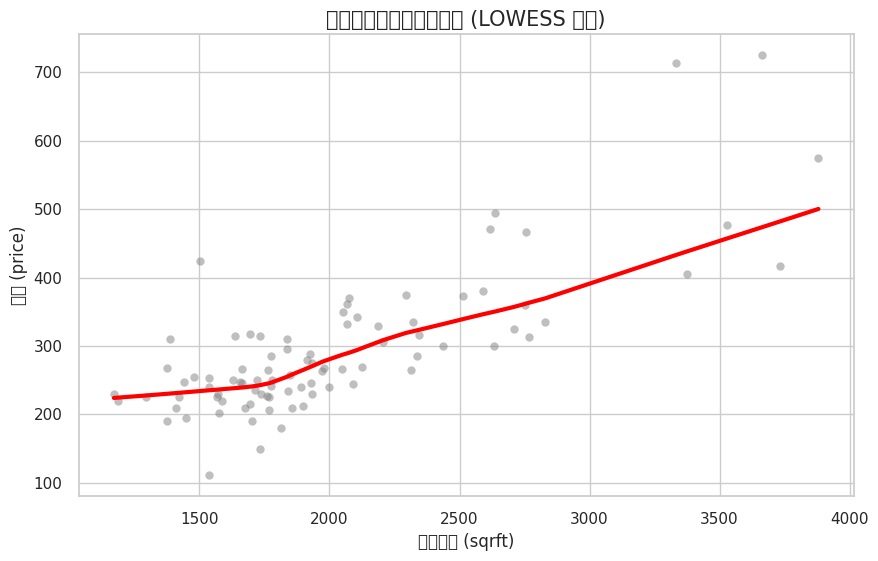

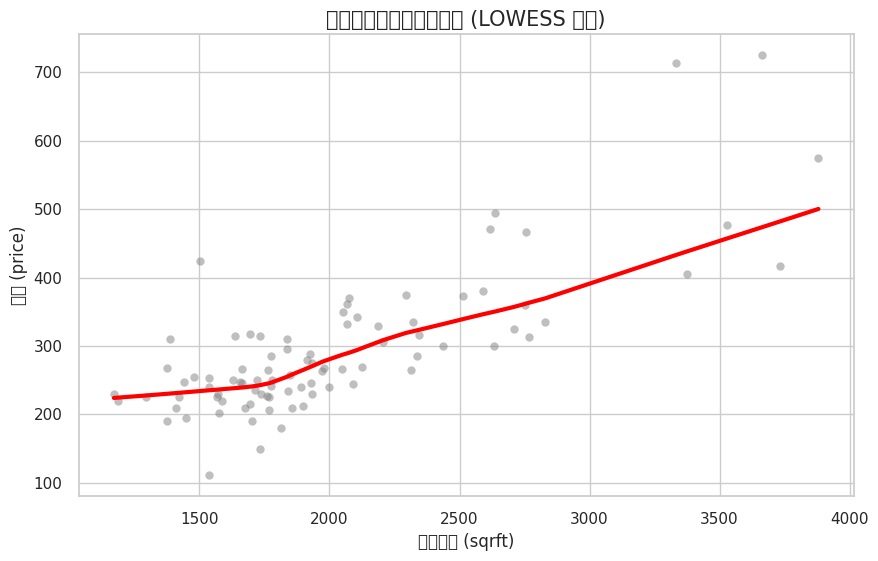

In [33]:
import seaborn as sns

%matplotlib inline
import matplotlib.pyplot as plt
# 设置绘图风格
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 使用对数坐标更能体现“增长率”的变化
# 如果红线呈现“S”型或先平后翘，即验证了你的三阶段理论
sns.regplot(x='sqrft', y='price', data=data, 
            lowess=True, 
            scatter_kws={'alpha':0.5, 'color':'gray'}, 
            line_kws={'color':'red', 'lw':3})

plt.title('房价与面积的非线性趋势 (LOWESS 平滑)', fontsize=15)
plt.xlabel('房屋面积 (sqrft)')
plt.ylabel('房价 (price)')
plt.show()

<Figure size 1000x600 with 0 Axes>

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

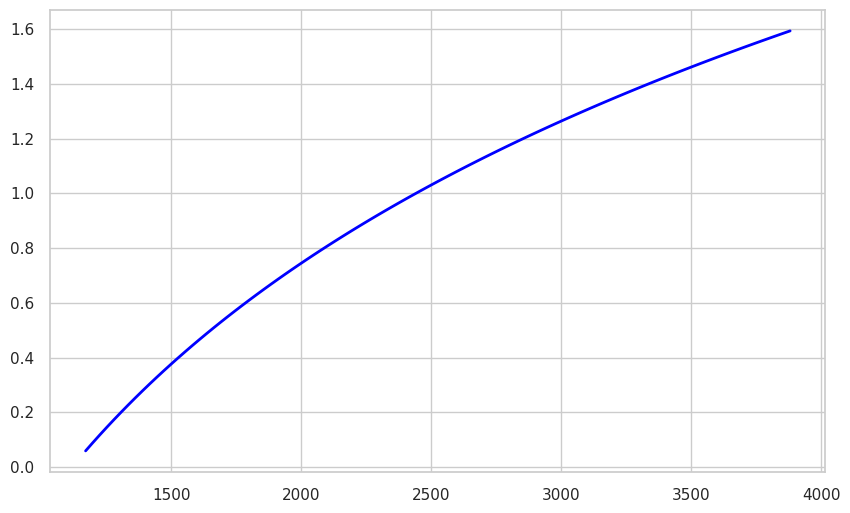

In [34]:
import numpy as np

# 假设我们使用的是你表现最好的二次方模型
# log(price) = b0 + b1*log(sqrft) + b2*log(sqrft)^2
# 增长率（弹性） = b1 + 2 * b2 * log(sqrft)

# 提取系数 (请确保 model_quadratic 是你之前拟合好的模型)
b1 = model_quadratic.params['np.log(sqrft)']
b2 = model_quadratic.params['I(np.log(sqrft) ** 2)']

# 创建一系列面积点
sqrft_range = np.linspace(data['sqrft'].min(), data['sqrft'].max(), 100)
log_sqrft_range = np.log(sqrft_range)

# 计算每个点的边际增长率
elasticity = b1 + 2 * b2 * log_sqrft_range

plt.figure(figsize=(10, 6))
plt.plot(sqrft_range, elasticity, color='blue', lw=2)
plt.axhline(y=elasticity, color='gray', linestyle='--', label='初始增长率')
plt.title('房价关于面积的“弹性”变化图', fontsize=15)
plt.xlabel('面积 (sqrft)')
plt.ylabel('增长弹性 (系数)')
plt.legend()
# 如果曲线是先下降后上升，完美符合你的“三阶段”猜想
plt.show()

<Figure size 1200x600 with 0 Axes>

<Axes: xlabel='sqrft', ylabel='residuals'>

<Axes: xlabel='sqrft', ylabel='residuals'>

Text(0.5, 1.0, '模型残差与面积分布图 (寻找异常增长区间)')

Text(0.5, 0, '面积 (sqrft)')

Text(0, 0.5, '预测残差 (越偏离0代表增长越超常规)')

/home/didiw/anaconda3/envs/py311/lib/python3.11/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/didiw/anaconda3/envs/py311/lib/python3.11/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/didiw/anaconda3/envs/py311/lib/python3.11/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27531 (\N{CJK UNIFIED IDEOGRAPH-6B8B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/didiw/anaconda3/envs/py311/lib/python3.11/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/didiw/anaconda3/envs/py311/lib/python3.11/site-packages/IPython/core/pylabtools.py

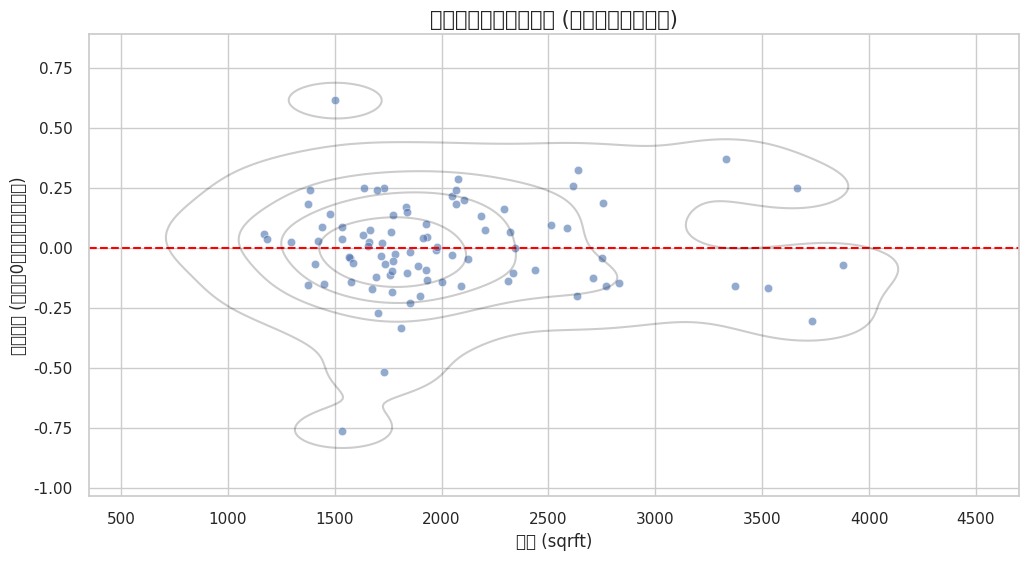

In [35]:
# 获取最优模型的残差
data['residuals'] = model_quadratic.resid

plt.figure(figsize=(12, 6))
# 绘制面积与残差的散点图
sns.scatterplot(x='sqrft', y='residuals', data=data, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')

# 添加一条拟合残差的线，看残差是否在特定面积区间有系统性偏离
sns.kdeplot(x=data['sqrft'], y=data['residuals'], levels=5, color="black", alpha=0.2)

plt.title('模型残差与面积分布图 (寻找异常增长区间)', fontsize=15)
plt.xlabel('面积 (sqrft)')
plt.ylabel('预测残差 (越偏离0代表增长越超常规)')
plt.show()

In [36]:
# 1. 计算学生化残差 (基于我们之前表现最好的二次方模型)
influence = model_quadratic.get_influence()
std_resid = influence.resid_studentized_internal

# 2. 设定阈值：通常绝对值大于 2 或 3 的被视为离群值
# 这里我们采取稍微严格的 2，看看能否过滤掉那几个“搅局”的点
outlier_mask = np.abs(std_resid) < 2
data_clean = data[outlier_mask]

print(f"原始样本量: {len(data)}, 清洗后样本量: {len(data_clean)}")
print(f"剔除了 {len(data) - len(data_clean)} 个离群点")

# 3. 在清洗后的数据上重新拟合你的“三阶段（三次方）模型”
model_clean_cubic = smf.ols('np.log(price) ~ np.log(sqrft) + I(np.log(sqrft)**2) + I(np.log(sqrft)**3)', 
                             data=data_clean).fit(cov_type='HC3')

print("--- 清洗后：三次方对数模型 Summary ---")
print(model_clean_cubic.summary())

原始样本量: 88, 清洗后样本量: 85
剔除了 3 个离群点
--- 清洗后：三次方对数模型 Summary ---
                            OLS Regression Results                            
Dep. Variable:          np.log(price)   R-squared:                       0.687
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     34.07
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           2.42e-14
Time:                        19:07:18   Log-Likelihood:                 37.481
No. Observations:                  85   AIC:                            -66.96
Df Residuals:                      81   BIC:                            -57.19
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------